# Preprocesamiento y escalamiento de datos — FIFA 23

En este ejercicio utilizaremos un dataset de jugadores de **FIFA 23** para introducir, de manera sencilla, técnicas comunes de preprocesamiento antes de construir modelos de Machine Learning.

En esta primera celda importamos las bibliotecas necesarias:
- **Pandas** y **NumPy** para trabajar con los datos.
- **StandardScaler** y **MinMaxScaler** para escalar variables numéricas.
- **ColumnTransformer** y **Pipeline** para organizar las transformaciones de forma reproducible.

> **Idea para clase:** por ahora nos concentraremos en entender las transformaciones. Más adelante, cuando se construya un modelo, estas transformaciones deberán ajustarse únicamente con los datos de entrenamiento para evitar fuga de información (*data leakage*).


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)

## 1. Carga del dataset

Cargamos el archivo CSV en un DataFrame llamado `df` y mostramos sus primeras filas.

**Qué observar:**
- Cada fila representa un jugador.
- Cada columna representa una característica del jugador.
- Todavía no estamos transformando los datos; solamente verificamos que se hayan cargado correctamente.


In [4]:
df = pd.read_csv("FIFA23_official_data.csv")

df.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,€91M,€115K,2312,Right,4.0,4.0,3.0,High/ Medium,Unique,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,€78.5M,€190K,2305,Right,3.0,3.0,4.0,High/ High,Unique,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,€46.5M,€46K,2303,Left,2.0,3.0,3.0,High/ High,Stocky (170-185),No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN
3,192985,K. De Bruyne,31,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,https://cdn.sofifa.net/flags/be.png,91,91,Manchester City,https://cdn.sofifa.net/teams/10/30.png,€107.5M,€350K,2303,Right,4.0,5.0,4.0,High/ High,Unique,Yes,"<span class=""pos pos13"">RCM","Aug 30, 2015",NaN,2025,181cm,70kg,€198.9M,17.0,NaN
4,224232,N. Barella,25,https://cdn.sofifa.net/players/224/232/23_60.png,Italy,https://cdn.sofifa.net/flags/it.png,86,89,Inter,https://cdn.sofifa.net/teams/44/30.png,€89.5M,€110K,2296,Right,3.0,3.0,3.0,High/ High,Normal (170-),Yes,"<span class=""pos pos13"">RCM","Sep 1, 2020",NaN,2026,172cm,68kg,€154.4M,23.0,NaN


## 2. Estructura del DataFrame

Utilizamos `df.info()` para conocer la estructura general del dataset.

**Qué observar:** número de registros, nombres de columnas, tipos de datos y presencia de valores nulos. Esta revisión ayuda a distinguir qué variables son numéricas y cuáles son categóricas antes de decidir cómo preprocesarlas.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        17660 non-null  int64  
 1   Name                      17660 non-null  str    
 2   Age                       17660 non-null  int64  
 3   Photo                     17660 non-null  str    
 4   Nationality               17660 non-null  str    
 5   Flag                      17660 non-null  str    
 6   Overall                   17660 non-null  int64  
 7   Potential                 17660 non-null  int64  
 8   Club                      17449 non-null  str    
 9   Club Logo                 17660 non-null  str    
 10  Value                     17660 non-null  str    
 11  Wage                      17660 non-null  str    
 12  Special                   17660 non-null  int64  
 13  Preferred Foot            17660 non-null  str    
 14  International Rep

## 3. Estadísticas descriptivas iniciales

Con `df.describe()` obtenemos un resumen estadístico de las variables numéricas.

**Qué observar:** media, desviación estándar, valores mínimos, máximos y cuartiles. Estas medidas permiten identificar diferencias de escala entre variables y entender por qué puede ser conveniente transformarlas.


In [6]:
df.describe()

,ID,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Kit Number
count,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17660.000000,17625.000000
mean,246319.424462,23.127746,63.369592,70.981200,1537.915855,1.106285,2.900340,2.297169,25.037957
std,31487.892861,4.639821,8.036268,6.529836,285.893809,0.407021,0.663523,0.754264,19.154116
min,16.000000,15.000000,43.000000,42.000000,749.000000,1.000000,1.000000,1.000000,1.000000
25%,240732.500000,20.000000,58.000000,67.000000,1387.000000,1.000000,3.000000,2.000000,11.000000
50%,257041.000000,22.000000,63.000000,71.000000,1548.000000,1.000000,3.000000,2.000000,22.000000
75%,263027.500000,26.000000,69.000000,75.000000,1727.000000,1.000000,3.000000,3.000000,32.000000
max,271340.000000,54.000000,91.000000,95.000000,2312.000000,5.000000,5.000000,5.000000,99.000000


## 4. Selección de variables numéricas

Para mantener el ejemplo sencillo seleccionamos tres variables numéricas: **Age**, **Overall** y **Potential**.

Estas columnas serán las que utilizaremos para demostrar el escalamiento. En la actividad de los alumnos, las variables seleccionadas dependerán de su propio dataset.


In [7]:
numeric_features = [
    'Age',
    'Overall',
    'Potential'
]

df[numeric_features].head()

,Age,Overall,Potential
0,27,87,88
1,27,86,87
2,30,85,85
3,31,91,91
4,25,86,89


## 5. Escala original de las variables

Antes de transformar los datos revisamos las estadísticas de las variables seleccionadas.

**Objetivo:** tener un punto de referencia para comparar posteriormente los valores originales con los escalados. El escalamiento cambia la representación numérica, pero no elimina la información relativa entre observaciones.


In [8]:
df[numeric_features].describe()

,Age,Overall,Potential
count,17660.000000,17660.000000,17660.000000
mean,23.127746,63.369592,70.981200
std,4.639821,8.036268,6.529836
min,15.000000,43.000000,42.000000
25%,20.000000,58.000000,67.000000
50%,22.000000,63.000000,71.000000
75%,26.000000,69.000000,75.000000
max,54.000000,91.000000,95.000000


## 6. Aplicación de `StandardScaler`

`StandardScaler` transforma cada variable utilizando su media y su desviación estándar. De forma conceptual:


**valor escalado = (valor original − media) / desviación estándar**

Después de la transformación, los datos quedan expresados en términos de cuántas desviaciones estándar se encuentran respecto de la media.

**Importante:** el orden relativo de los jugadores y la forma general de la distribución se conservan; lo que cambia es la escala numérica.


In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[numeric_features]
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=[f"{c}_scaled" for c in numeric_features]
)

scaled_df.head()

,Age_scaled,Overall_scaled,Potential_scaled
0,0.834593,2.940553,2.606387
1,0.834593,2.816114,2.453240
2,1.481188,2.691675,2.146945
3,1.696720,3.438311,3.065830
4,0.403530,2.816114,2.759535


## 7. Comparación: antes y después

Colocamos lado a lado los valores originales y los valores transformados con `StandardScaler`.

**Qué observar:**
- Los números son diferentes.
- Las observaciones siguen representando a los mismos jugadores.
- Un valor escalado positivo indica que está por encima de la media; uno negativo, por debajo.

Esta comparación permite visualizar claramente qué significa escalar una variable.


In [10]:
comparison = pd.concat(
    [
        df[numeric_features].head(),
        scaled_df.head()
    ],
    axis=1
)

comparison

,Age,Overall,Potential,Age_scaled,Overall_scaled,Potential_scaled
0,27,87,88,0.834593,2.940553,2.606387
1,27,86,87,0.834593,2.816114,2.453240
2,30,85,85,1.481188,2.691675,2.146945
3,31,91,91,1.696720,3.438311,3.065830
4,25,86,89,0.403530,2.816114,2.759535


## 8. Media después de `StandardScaler`

Calculamos la media de las variables escaladas. En teoría, después de aplicar `StandardScaler`, la media queda aproximadamente en **0**.

Es posible observar valores extremadamente pequeños en lugar de cero exacto debido a la precisión numérica de la computadora.


In [11]:
scaled_df.mean()

Age_scaled          1.287507e-16
Overall_scaled     -1.030005e-16
Potential_scaled   -5.665029e-16
dtype: float64

## 9. Desviación estándar después de `StandardScaler`

Ahora revisamos la dispersión de las variables escaladas. `StandardScaler` busca que la desviación estándar sea aproximadamente **1**.

> Nota didáctica: Scikit-learn y Pandas pueden usar convenciones ligeramente distintas al calcular la desviación estándar, por lo que el resultado mostrado por `pandas.DataFrame.std()` puede no ser exactamente 1.


In [12]:
scaled_df.std()

Age_scaled          1.000028
Overall_scaled      1.000028
Potential_scaled    1.000028
dtype: float64

## 10. Otra técnica: `MinMaxScaler`

Como comparación, aplicamos `MinMaxScaler` a las mismas variables. Esta técnica reescala los valores para colocarlos, por defecto, dentro del intervalo **0 a 1**.

A diferencia de `StandardScaler`, aquí no buscamos media 0 y desviación estándar 1. Ambas técnicas conservan el orden de los datos, pero cambian su escala de manera diferente.


In [13]:
minmax = MinMaxScaler()

minmax_data = minmax.fit_transform(
    df[numeric_features]
)

minmax_df = pd.DataFrame(
    minmax_data,
    columns=[
        f"{c}_minmax"
        for c in numeric_features
    ]
)

minmax_df.head()

,Age_minmax,Overall_minmax,Potential_minmax
0,0.307692,0.916667,0.867925
1,0.307692,0.895833,0.849057
2,0.384615,0.875000,0.811321
3,0.410256,1.000000,0.924528
4,0.256410,0.895833,0.886792


## 11. Visualización de una variable antes y después

Comparamos mediante histogramas la variable **Age** antes y después de aplicar `StandardScaler`.

**Qué observar:** la escala del eje horizontal cambia, pero la forma de la distribución permanece esencialmente igual. Esto ayuda a reforzar que el escalamiento modifica la unidad de medida, no la estructura fundamental de los datos.


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].hist(df['Age'], bins=20)
axes[0].set_title('Age - Antes del escalamiento')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Después
axes[1].hist(scaled_df['Age_scaled'], bins=20)
axes[1].set_title('Age - Después de StandardScaler')
axes[1].set_xlabel('Valor escalado')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

## 12. Relación entre dos variables antes y después

Ahora utilizamos un gráfico de dispersión para comparar la relación entre **Age** y **Overall**.

**Qué observar:** los valores de los ejes cambian, pero el patrón formado por los puntos se conserva. La relación entre las observaciones no desaparece por el hecho de escalar las variables.


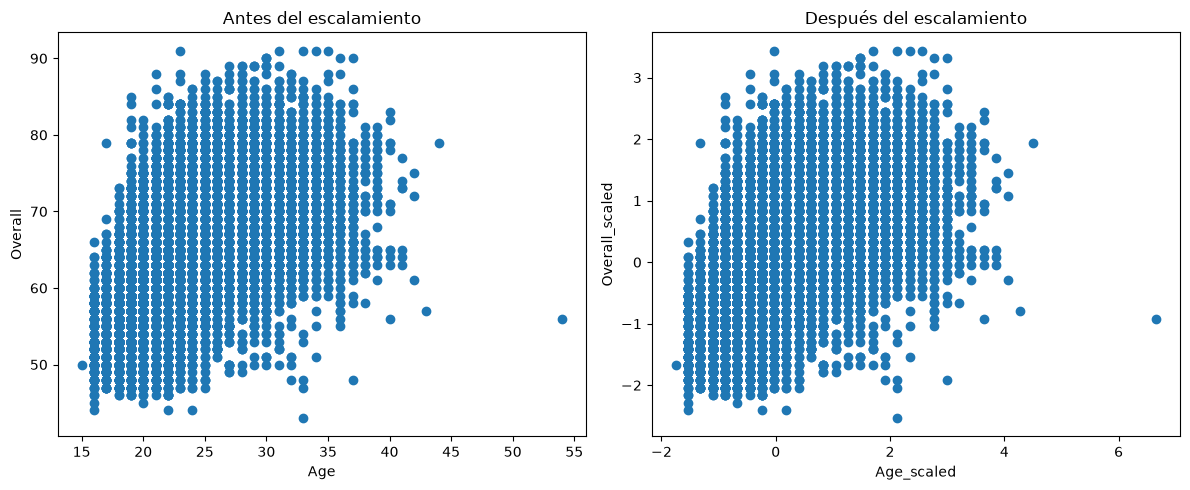

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Antes
ax[0].scatter(df['Age'], df['Overall'])
ax[0].set_title('Antes del escalamiento')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Overall')

# Después
ax[1].scatter(
    scaled_df['Age_scaled'],
    scaled_df['Overall_scaled']
)
ax[1].set_title('Después del escalamiento')
ax[1].set_xlabel('Age_scaled')
ax[1].set_ylabel('Overall_scaled')

plt.tight_layout()
plt.show()

## 13. Comparación visual de todas las variables numéricas

Generamos histogramas para cada una de las variables seleccionadas, mostrando su versión original y su versión escalada.

Esta visualización permite comprobar simultáneamente que **Age**, **Overall** y **Potential** cambian de escala mientras conservan la forma de sus distribuciones.


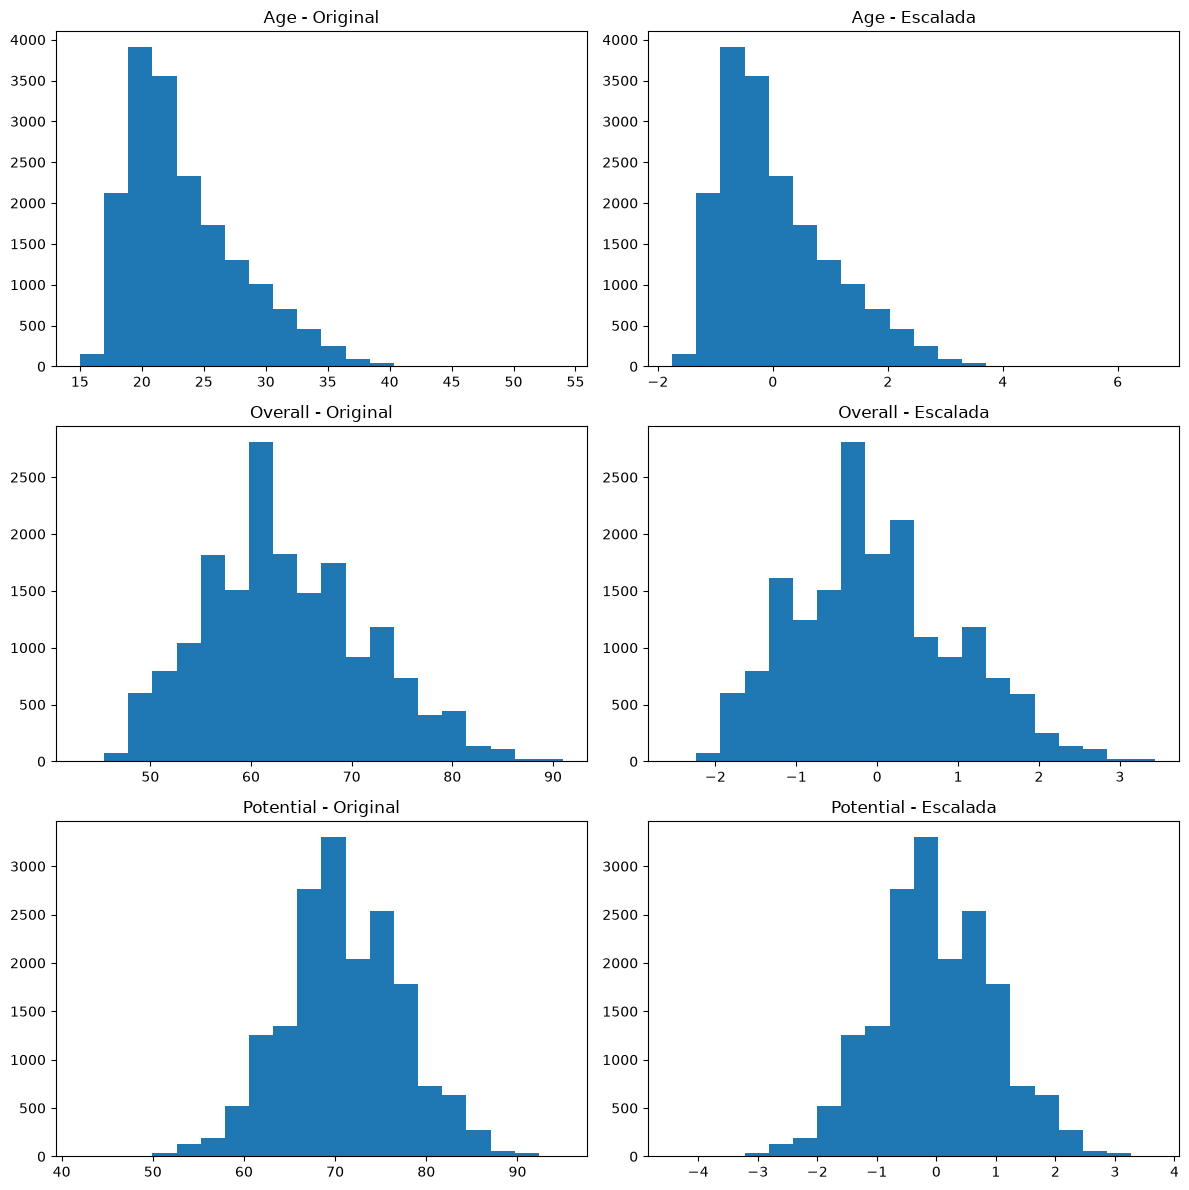

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(numeric_features),
    ncols=2,
    figsize=(12, 12)
)

for i, feature in enumerate(numeric_features):

    # Antes
    axes[i, 0].hist(df[feature], bins=20)
    axes[i, 0].set_title(f'{feature} - Original')

    # Después
    axes[i, 1].hist(
        scaled_df[f'{feature}_scaled'],
        bins=20
    )
    axes[i, 1].set_title(f'{feature} - Escalada')

plt.tight_layout()
plt.show()

## 14. Segunda presentación de los histogramas

Repetimos la comparación con una presentación visual diferente para facilitar la lectura en clase.

El propósito sigue siendo el mismo: observar que `StandardScaler` cambia los valores y el rango de cada variable, pero no altera el orden de las observaciones ni la forma esencial de la distribución.


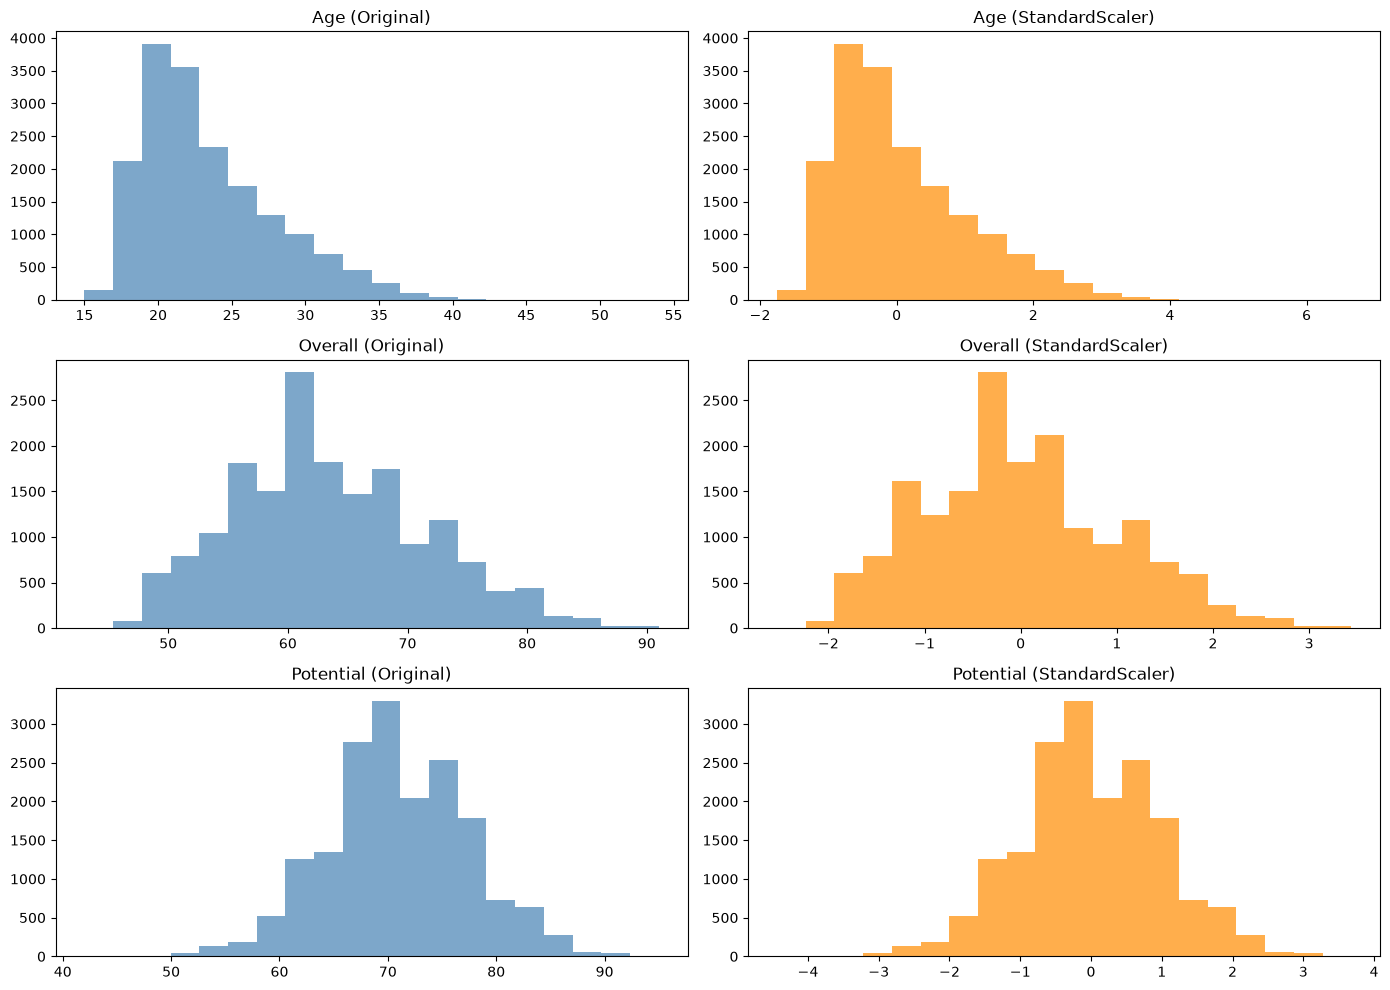

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(numeric_features),
    2,
    figsize=(14, 10)
)

for i, feature in enumerate(numeric_features):

    axes[i, 0].hist(
        df[feature],
        bins=20,
        color='steelblue',
        alpha=0.7
    )

    axes[i, 0].set_title(
        f'{feature} (Original)'
    )

    axes[i, 1].hist(
        scaled_df[f'{feature}_scaled'],
        bins=20,
        color='darkorange',
        alpha=0.7
    )

    axes[i, 1].set_title(
        f'{feature} (StandardScaler)'
    )

plt.tight_layout()
plt.show()

## 15. La media antes y después del escalamiento

Añadimos una línea vertical que representa la media de cada variable.

**Qué observar:**
- En los datos originales, la media se encuentra en el valor correspondiente a la unidad original.
- Después de `StandardScaler`, la media queda aproximadamente en **0**.

Esta gráfica conecta visualmente la transformación con la fórmula utilizada por `StandardScaler`.


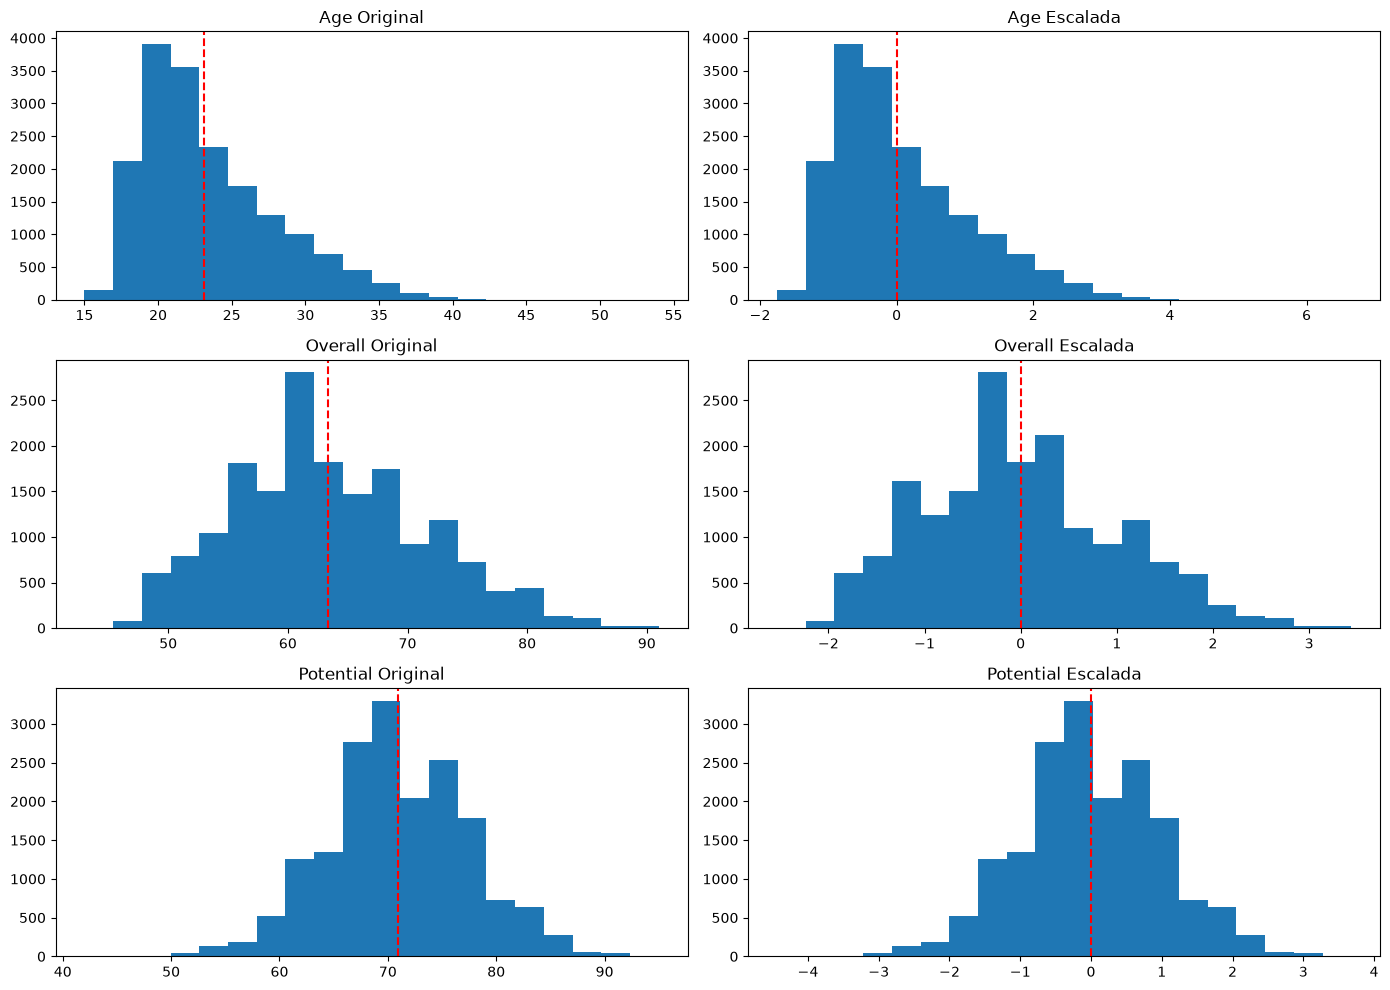

In [ ]:
fig, axes = plt.subplots(
    len(numeric_features),
    2,
    figsize=(14, 10)
)

for i, feature in enumerate(numeric_features):

    axes[i,0].hist(df[feature], bins=20)
    axes[i,0].axvline(
        df[feature].mean(),
        color='red',
        linestyle='--'
    )
    axes[i,0].set_title(f'{feature} Original')

    axes[i,1].hist(
        scaled_df[f'{feature}_scaled'],
        bins=20
    )
    axes[i,1].axvline(
        scaled_df[f'{feature}_scaled'].mean(),
        color='red',
        linestyle='--'
    )
    axes[i,1].set_title(f'{feature} Escalada')

plt.tight_layout()
plt.show()


## 16. Selección de variables categóricas

Hasta ahora trabajamos con variables numéricas. También existen columnas categóricas que requieren un tratamiento diferente.

Seleccionamos **Nationality** y **Preferred Foot** como ejemplo. Estas variables no deben escalarse con `StandardScaler`; primero necesitan una codificación adecuada.


In [ ]:
categorical_features = [
    'Nationality',
    'Preferred Foot'
]

## 17. Verificación de las variables categóricas

Mostramos la lista definida en la celda anterior para verificar qué columnas serán tratadas como categóricas dentro del proceso de preprocesamiento.


In [ ]:
categorical_features

['Nationality', 'Preferred Foot']

## 18. Organización con `ColumnTransformer`

`ColumnTransformer` permite indicar distintas transformaciones para distintos grupos de columnas:

- A las variables **numéricas** se les aplica `StandardScaler`.
- A las variables **categóricas** se les aplica `OneHotEncoder`.

Esta organización hace el proceso más claro, reproducible y menos propenso a errores que transformar manualmente cada conjunto de variables. `handle_unknown='ignore'` permite manejar categorías nuevas sin detener la transformación.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

## 19. Construcción de un `Pipeline`

Creamos un `Pipeline` que contiene el preprocesador definido anteriormente. Aunque en este ejemplo todavía no agregamos un algoritmo de Machine Learning, esta estructura permite incorporar posteriormente un modelo en el mismo flujo.

**Ventaja:** las mismas transformaciones pueden aplicarse de manera consistente a los datos que entrenan el modelo y a los datos nuevos.


In [ ]:
pipeline = Pipeline(
    steps=[
        ('preprocessing',
         preprocessor)
    ]
)

## 20. Ejecución del proceso completo

Finalmente ejecutamos el `Pipeline` sobre el DataFrame y revisamos las dimensiones del resultado transformado. El número de columnas puede aumentar porque `OneHotEncoder` genera nuevas columnas para representar las categorías.

### Conexión con la actividad
Este ejemplo cumple la intención de organizar el preprocesamiento de forma reproducible mediante `ColumnTransformer` y `Pipeline`.

**Sin embargo, hay una consideración fundamental para la etapa de modelado:** en este notebook se ejecuta `fit_transform(df)` únicamente con fines demostrativos. Cuando los alumnos construyan un modelo, deberán primero separar los datos en entrenamiento y prueba. El escalador y el codificador deben **ajustarse (`fit`) solamente con los datos de entrenamiento** y después utilizarse para transformar entrenamiento y prueba. De esta manera se evita que información del conjunto de prueba influya indirectamente en el entrenamiento, fenómeno conocido como **fuga de información o data leakage**.

### ¿Por qué importa la escala?
Algunos algoritmos son sensibles a la escala porque utilizan distancias, magnitudes o procesos de optimización. Si una variable tiene valores mucho mayores que otra, puede dominar el cálculo aunque no sea necesariamente más importante. El escalamiento ayuda a colocar las variables en escalas comparables.

> Para la actividad, los alumnos no tienen que utilizar estas mismas columnas ni este mismo dataset: deben aplicar la misma lógica a las variables apropiadas de sus propios datos.


In [ ]:
X_processed = pipeline.fit_transform(df)

X_processed.shape

(17660, 166)